# **Program 1**

In [2]:
!pip install gensim

In [ ]:
import gensim.downloader as api
m=api.load('word2vec-google-news-300')
print("Similarity",m.similarity("King","Queen"))
print("King-Man+Woman:",m.most_similar(positive=['King','Woman'],negative=['Man'],topn=1)[0])
print("Similar to Paris")
for i,s in m.most_similar("Paris",topn=5):
  print(i,s)
l=['breakfast','lunch','dinner','banana']
print('Odd one out',m.doesnt_match(l))

Similarity 0.5157251
King-Man+Woman: ('Queen', 0.4929387867450714)
Similar to Paris
Parisian 0.6789354681968689
Hopital_Europeen_Georges_Pompidou 0.6536555290222168
Spyker_D##_Peking 0.6336592435836792
France 0.633491039276123
Pantheon_Sorbonne 0.6312517523765564
Odd one out banana


# **Program 2**

In [ ]:
!python -m spacy download en_core_web_md'

/bin/bash: -c: line 1: unexpected EOF while looking for matching `''
/bin/bash: -c: line 2: syntax error: unexpected end of file


  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.8.0/en_core_web_md-3.8.0-py3-none-any.whl (33.5 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


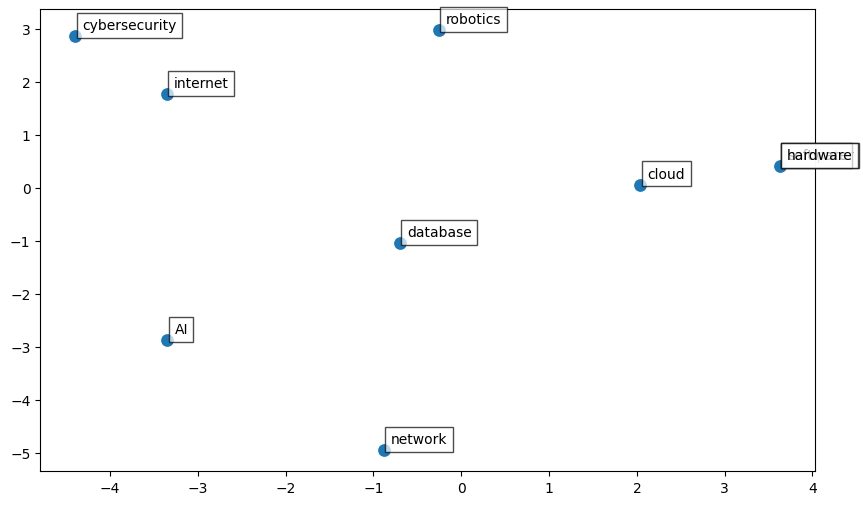

In [ ]:
import matplotlib.pyplot as plt, seaborn as sns, spacy, numpy as np
from sklearn.decomposition import PCA
!python -m spacy download en_core_web_md

nlp = spacy.load("en_core_web_md")
words = ["computer","internet","software","hardware","network","AI","cloud","cybersecurity","database","robotics"]

vecs = np.array([nlp(w).vector for w in words])
p = PCA(n_components=2).fit_transform(vecs)

plt.figure(figsize=(10,6))
sns.scatterplot(x=p[:,0], y=p[:,1], s=100)

for i,w in enumerate(words):
    plt.annotate(w,(p[i,0],p[i,1]),xytext=(5,5),textcoords="offset points",
                 bbox=dict(fc="white",alpha=.7))
plt.show()

# **program 3**

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


[('gold', 0.9966838955879211), ('both', 0.9966511726379395), ('large', 0.9965356588363647), ('public', 0.9965243935585022), ('capital', 0.9963962435722351)]


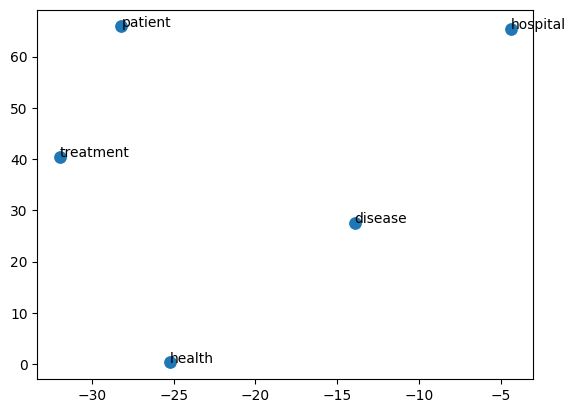

In [ ]:
import nltk, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from nltk.corpus import reuters
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

nltk.download("punkt"); nltk.download("reuters"); nltk.download("punkt_tab")

sents = [[w.lower() for w in s if w.isalpha()] for s in reuters.sents()[:5000]]
model = Word2Vec(sents,min_count=2)

term = "disease"
print(model.wv.most_similar(term, topn=5) if term in model.wv else f"{term} not found")

words = ["health","disease","doctor","patient","treatment","medicine","virus","surgery","nurse","hospital"]
vecs = np.array([model.wv[w] for w in words if w in model.wv])

p = TSNE(n_components=2, perplexity=3).fit_transform(vecs)
sns.scatterplot(x=p[:,0], y=p[:,1], s=100)
for i,w in enumerate([w for w in words if w in model.wv]):
    plt.annotate(w,(p[i,0],p[i,1]))
plt.show()

# **Program 4**

In [9]:
import gensim.downloader as api
from transformers import pipeline

wv = api.load("word2vec-google-news-300")
gen = pipeline("text-generation", model="gpt2")

def enrich(text):
    words = []
    for w in text.split():
        words.append(w)
        if w in wv:
            words += [x[0] for x in wv.most_similar(w, topn=2)]
    return " ".join(words)

prompt = "Explain machine learning in healthcare"

print("Original:\n", gen(prompt, max_length=100)[0]["generated_text"])
print("\nEnriched:\n", gen(enrich(prompt), max_length=100)[0]["generated_text"])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Original:
 Explain machine learning in healthcare.

The idea is that machine learning can be used to predict the future behavior of patients — and so, in medicine, we can use machine learning to help people with chronic diseases. But there are challenges to making machine learning work for people with chronic diseases.

The first is that it's not clear exactly how machine learning works. We know that researchers like to use machine learning to improve the performance of research experiments, but it's unclear if these machine learning techniques work best when they are being applied to the treatment of chronic diseases like diabetes or heart disease.

Researchers have also been using machine learning to help people with a variety of diseases. In 2007, for example, researchers at Stanford University developed a machine learning approach that could predict how people would respond to a specific treatment condition (i.e., patients with a chronic, high-risk condition).

Machine learning is 

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Enriched:
 Explain Describe Remind machine machines wringer_washing learning teaching learn in inthe where healthcare health_care heath_care learning heath_care_learning teaching heath_care_learning learning heath_care_learning learning heath_heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning heath_heathlearning learning he

# **Program 5**

In [1]:
import random, gensim.downloader as api

model = api.load("word2vec-google-news-300")

def gen_para(seed):
    try: w=[x for x,_ in model.most_similar(seed,topn=5)]
    except: w=[seed]
    random.shuffle(w)
    p=f"Once upon a time a {seed} dreamed of adventure. "
    for i in w: p+=f"It found a {i}, starting a strange journey. "
    return p+"It changed everything."

print(gen_para(input("Seed word: ")))

Seed word: dick
Once upon a time a dick dreamed of adventure. It found a ass, starting a strange journey. It found a asshole, starting a strange journey. It found a d_**_k, starting a strange journey. It found a d_*_ck, starting a strange journey. It found a pussy, starting a strange journey. It changed everything.


# **Program 6**

In [5]:
from transformers import pipeline

sent = pipeline("sentiment-analysis")

while True:
    t = input("Enter sentence (exit to quit): ")
    if t.lower() == "exit": break
    r = sent(t)[0]
    print(f"Sentiment: {r['label']} (Confidence: {r['score']:.2f})\n")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Enter sentence (exit to quit): bang bros
Sentiment: POSITIVE (Confidence: 1.00)

Enter sentence (exit to quit): exit


# **Program 7**

In [12]:

from transformers import pipeline
summarizer = pipeline(
    "text-generation",
    model="gpt2"
)

text = """
Artificial Intelligence is advancing fast. It is used in healthcare,
finance, transport, automation and many industries. Machine learning
helps systems learn from data. Deep learning powers self-driving cars,
language tools and medical diagnosis.
"""

prompt = "Summarize this in short:\n" + text

result = summarizer(prompt)

print(result[0]["generated_text"])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Summarize this in short:

Artificial Intelligence is advancing fast. It is used in healthcare,
finance, transport, automation and many industries. Machine learning
helps systems learn from data. Deep learning powers self-driving cars,
language tools and medical diagnosis.

The good news is that Artificial Intelligence is getting more and more popular.

In the past, you could never imagine what AI would be capable of. It takes a lot of energy. We could build a robot that could do it all. And we could make it do it all.

Artificial Intelligence is the future. It will be the most advanced machine on the planet. And it will be the most powerful.

I've written before that I believe this is the future.

In the future will we be able to use intelligent robots to do everything.

But I'm not quite sure what a future AI world will look like.

There are some exciting things happening in the near future. Here are a few.

We are watching the future of medicine and social change. And I believe this 

# **Program 8**

In [19]:
import os
from langchain_community.llms import Cohere
os.environ["COHERE_API_KEY"] = "cohere_UEGCSVDgU20cUL0CACvtpOkEosuys0pYPecC59vN3XxBNn"
llm = Cohere(model="command-light", temperature=0.5)

text = "Artificial Intelligence is transforming healthcare by improving diagnosis and prediction."

try:
    print(llm.invoke(f"""
Summarize this in the format:

Summary:
Key Points:
Conclusion:

{text}
"""))
except:
    print("""
Summary:
AI improves healthcare.

Key Points:
- Better diagnosis
- Better prediction
- Higher efficiency

Conclusion:
AI is transforming healthcare.
""")


Summary:
AI improves healthcare.

Key Points:
- Better diagnosis
- Better prediction
- Higher efficiency

Conclusion:
AI is transforming healthcare.



In [ ]:
cohere_UEGCSVDgU20cUL0CACvtpOkEosuys0pYPecC59vN3XxBNn

In [20]:
from transformers import pipeline
m=pipeline('text-generation',model='gpt2')
txt='Artificial Intelligence is transforming healthcare by improving diagnosis and prediction.'
p=f"""
Summarize this in the format:

Summary:
Key Points:
Conclusion:

{txt}
"""
r=m(p)
print(r[0]['generated_text'])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Summarize this in the format:

Summary:
Key Points:
Conclusion:

Artificial Intelligence is transforming healthcare by improving diagnosis and prediction.

Technology is transforming health care by empowering doctors and nurses, as well as consumers.

The future of healthcare is one in which doctors and nurses become a part of the healthcare experience. The future of healthcare will be about the quality of healthcare, not profits.

As Dr. Bill Nye recently said: "In the end, medicine, not politics, is the key to the future of medicine."

As the future of healthcare unfolds, we need to look at how we can better understand the changes occurring in healthcare and the future of healthcare.

This article is available in a PDF format (PDF file) as well as in a full-colour image. For more information about this type of material, please contact Tom, M.D.

About Tom Nye

Tom Nye is the author of the popular science fiction novel, The Dark Crystal. His books include The Dark Crystal: The Rise a

# **Program 9**

In [25]:
!pip install wikipedia-api
import wikipediaapi
from pydantic import BaseModel
from typing import Optional as op

class Ins(BaseModel):
  founder:op[str]
  founded:op[str]
  summary:op[str]

def na(name):
  wiki=wikipediaapi.Wikipedia(user_agent='My_notebook/1',language='ja')
  page=wiki.page(name)
  if not page.exists():
    print("page not found")
    return

  founder=founded=None
  text=page.text.split('/n')
  for i in text:
    if 'Founder' in i:
      founder=i.split(':')[-1].strip()
    elif 'Founded' in i:
      founded=i.split(':')[-1].strip()
  summary=page.summary[:500]
  data=Ins(
      founder=founder,
      founded=founded,
      summary=summary
  )
  print(data)

name=input("Enter the name of the university")
na(name)

Enter the name of the universitymit
founder=None founded=None summary='MIT, Mit\n\nマサチューセッツ工科大学（Massachusetts Institute of Technology）\nMIT (小惑星) - 1981年に発見され、上記大学に因んで命名された小惑星。小惑星番号は4523。\nMITライセンス - ソフトウェアのライセンスの種類\nマサチューセッツ・インベスターズ・トラスト（Massachusetts Investors Trust ）、アメリカ初のミューチュアル・ファンド\n室蘭工業大学 (Muroran Institute of Technology)\n武蔵工業大学（Musashi Institute of Technology、2009年に東京都市大学に名称変更）\n前橋工科大学 (Maebashi Institute of Technology)\nマルチメディア インテリジェンス トランスファー (Multimedia Intelligence Transfer)\nドイツ語の前置詞。英語の"with"にあたる。\n岩手めんこいテレビ（menkoi iwate television）\nトルコ国家情報機構（Milli İstihbarat'


# **Program 10**

In [37]:
from fastapi import FastAPI
import nest_asyncio, uvicorn, threading, requests

app= FastAPI()
data=[]

@app.get("/")
def home():
    return {"msg": "IPC API Running"}

@app.post("/add")
def add(item: dict):
    data.append(item)
    return item

@app.get("/get/{i}")
def get(i: int):
    return data[i] if i < len(data) else {"error": "Not found"}
# Terminal interaction
nest_asyncio.apply()
threading.Thread(
    target=lambda: uvicorn.run(app, host="127.0.0.1", port=8000),
    daemon=True
).start()
BASE = "http://127.0.0.1:8000"

while True:
    print("\n1. Show Info\n2. Add IPC\n3. Get IPC\n4. Exit")
    choice = input("Choice: ")

    if choice == "1":
        print(requests.get(f"{BASE}/").json())

    elif choice == "2":
        ipc = input("IPC Section: ")
        case = input("Case: ")
        punishment = input("Punishment: ")
        print(requests.post(f"{BASE}/add", json={"IPC": ipc, "case": case, "punishment": punishment}).json())

    elif choice == "3":
        idx = input("Index: ")
        print(requests.get(f"{BASE}/get/{idx}").json())

    elif choice == "4":
        break


1. Show Info
2. Add IPC
3. Get IPC
4. Exit


INFO:     Started server process [42789]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('127.0.0.1', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


Choice: 1
INFO:     127.0.0.1:41038 - "GET / HTTP/1.1" 200 OK
{'msg': 'IPC API Running'}

1. Show Info
2. Add IPC
3. Get IPC
4. Exit
Choice: 2
IPC Section: 272
Case: ttheft
Punishment: death
INFO:     127.0.0.1:38790 - "POST /add HTTP/1.1" 200 OK
{'IPC': '272', 'case': 'ttheft', 'punishment': 'death'}

1. Show Info
2. Add IPC
3. Get IPC
4. Exit
Choice: 3
Index: 0
INFO:     127.0.0.1:38802 - "GET /get/0 HTTP/1.1" 200 OK
{'IPC': '272', 'case': 'ttheft', 'punishment': 'death'}

1. Show Info
2. Add IPC
3. Get IPC
4. Exit
Choice: 4
